In [3]:
import os
import numpy as np
import pandas as pd
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import json
import enreg.tools.general as g

hep.style.use("CMS")
%matplotlib inline

In [4]:
#Loading models
model_path = "/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/dm_multiclass_epoch100/dm_multiclass/ParticleTransformer"


In [5]:
# Load test data
zh_test_path = os.path.join(model_path, "zh_test.parquet")
z_test_path = os.path.join(model_path, "z_test.parquet")
qq_test_path = os.path.join(model_path, "qq_test.parquet")

# Load and extract dm_multiclass data
zh_full = ak.from_parquet(zh_test_path)
z_full = ak.from_parquet(z_test_path)
qq_full = ak.from_parquet(qq_test_path)

In [6]:
#inspect the correct field
print("ZH fields:", zh_full.fields)
print("Z fields:", z_full.fields)
print("QQ fields:", qq_full.fields)
# Access dm_multiclass - convert to list if needed
zh_test = zh_full["dm_multiclass"]
z_test = z_full["dm_multiclass"]
qq_test = qq_full["dm_multiclass"]



ZH fields: ['dm_multiclass']
Z fields: ['dm_multiclass']
QQ fields: ['dm_multiclass']


In [7]:
type(zh_test)

awkward.highlevel.Record

In [8]:
zh_test.fields

['pred', 'target']

In [9]:
len(zh_test["pred"])

1042833

In [10]:
len(zh_test["target"])


1042833

In [11]:
print(f"ZH test set size: {len(zh_test['pred'])}")
print(f"Z test set size: {len(z_test['pred'])}")
print(f"QQ test set size: {len(qq_test['pred'])}")

ZH test set size: 1042833
Z test set size: 839828
QQ test set size: 1902388


In [12]:
#Inspecting data structure

print("ZH test type:", type(zh_test))
print("ZH test fields:", zh_test.fields if hasattr(zh_test, "fields") else "N/A")

# A Record is not a dataset → just inspect its fields directly
print("\nZH test target (first 20):", zh_test.target[:20])

print("\nZH test pred type:", type(zh_test.pred))
print("ZH test pred shape:", np.array(zh_test.pred).shape)
print("ZH test pred (first 5):", zh_test.pred[:5])

# Check unique classes
print("\nUnique target classes in zh_test:", np.unique(ak.to_numpy(zh_test.target)))
print("Unique target classes in z_test:", np.unique(ak.to_numpy(z_test.target)))
print("Unique target classes in qq_test:", np.unique(ak.to_numpy(qq_test.target)))

ZH test type: <class 'awkward.highlevel.Record'>
ZH test fields: ['pred', 'target']

ZH test target (first 20): [3, 1, 1, 2, 3, 1, 1, 4, 1, 1, 1, 2, 0, 0, 0, 0, 1, 1, 0, 2]

ZH test pred type: <class 'awkward.highlevel.Array'>
ZH test pred shape: (1042833,)
ZH test pred (first 5): [3, 1, 1, 2, 3]

Unique target classes in zh_test: [0 1 2 3 4 5]
Unique target classes in z_test: [0 1 2 3 4 5]
Unique target classes in qq_test: [5]


In [13]:
# Convert to numpy
zh_target = ak.to_numpy(zh_test.target)
zh_pred_proba = ak.to_numpy(zh_test.pred)
zh_pred = zh_pred_proba  # already class labels

z_target = ak.to_numpy(z_test.target)
z_pred_proba = ak.to_numpy(z_test.pred)
z_pred = z_pred_proba  # already class labels

qq_target = ak.to_numpy(qq_test.target)
qq_pred_proba = ak.to_numpy(qq_test.pred)
qq_pred = qq_pred_proba  # already class labels

print(f"ZH: shape={zh_pred.shape}, n_classes={len(np.unique(zh_target))}")
print(f"Z: shape={z_pred.shape}, n_classes={len(np.unique(z_target))}")
print(f"QQ: shape={qq_pred.shape}, n_classes={len(np.unique(qq_target))}")

ZH: shape=(1042833,), n_classes=6
Z: shape=(839828,), n_classes=6
QQ: shape=(1902388,), n_classes=1


## Class Distribution

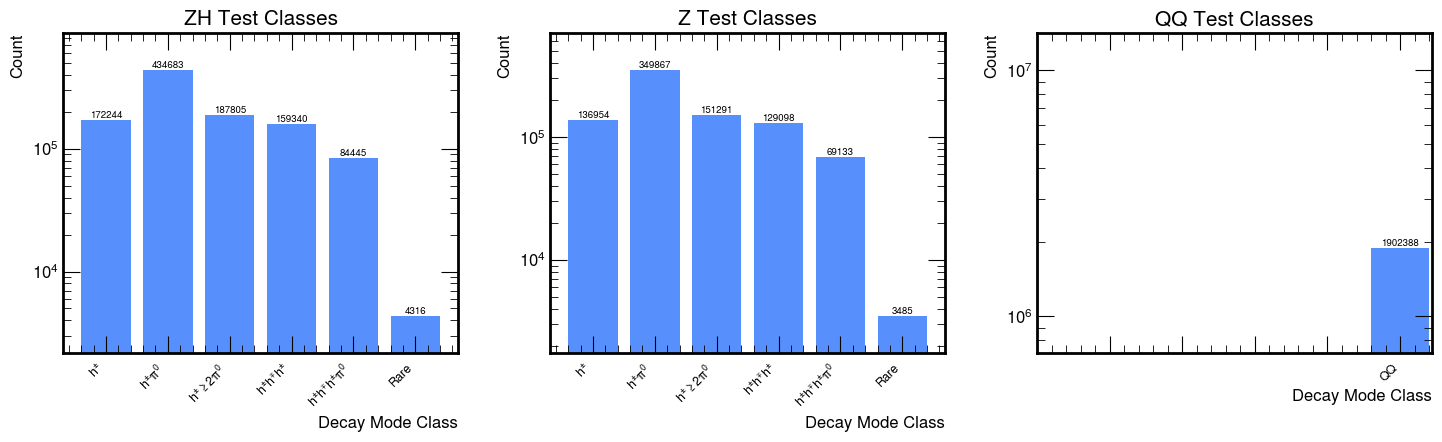

In [14]:
# Define class names for tau decay modes
class_names = [
    r'$h^{\pm}$',
    r'$h^{\pm}\pi^0$',
    r'$h^{\pm}\geq 2\pi^0$',
    r'$h^{\pm}h^{\mp}h^{\pm}$',           
    r'$h^{\pm}h^{\mp}h^{\pm}\pi^0$',      
    'Rare'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, target, name in [(axes[0], zh_target, "ZH"), 
                          (axes[1], z_target, "Z"), 
                          (axes[2], qq_target, "QQ")]:
    unique, counts = np.unique(target, return_counts=True)
    ax.bar(unique, counts)
    ax.set_xlabel("Decay Mode Class", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"{name} Test Classes", fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_yscale("log")
    # Set x-axis tick labels to class names
    ax.set_xticks(range(len(class_names)))
    # For QQ, use "QQ" instead of "Rare" for class 5
    if name == "QQ":
        labels_to_use = class_names[:-1] + ["QQ"]
    else:
        labels_to_use = class_names
    ax.set_xticklabels([labels_to_use[i] if i in unique else '' for i in range(len(labels_to_use))], 
                        rotation=45, ha='right', fontsize=9)
    #Fix tight limits:
    ax.margins(y=0.15)
    # Labels
    for i, c in zip(unique, counts):
        ax.text(i, c, str(c), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## Global Metrics

In [15]:
class_names = ['OneProng0PiZero', 'OneProng1PiZero', 'OneProng2+PiZero', 
               'ThreeProng0PiZero', 'ThreeProng1+PiZero', 'Rare/Remainder']

print("Decay Mode Class Mapping:")
for i, name in enumerate(class_names):
    print(f"  {i} → {name}")

def compute_metrics(y_true, y_pred, y_pred_proba, dataset_name):
    """Compute comprehensive metrics for multiclass classification"""
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"{dataset_name} Test Set Metrics")
    print(f"{'='*60}")
    print(f"Accuracy (overall):        {acc:.4f}")
    print(f"F1 Score (macro avg):      {f1_macro:.4f}")
    print(f"F1 Score (weighted avg):   {f1_weighted:.4f}")
    print(f"Precision (macro avg):     {precision_macro:.4f}")
    print(f"Recall (macro avg):        {recall_macro:.4f}")
    print(f"Number of samples:         {len(y_true)}")
    print(f"Number of classes:         {len(np.unique(y_true))}")
    
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro
    }

metrics_zh = compute_metrics(zh_target, zh_pred, zh_pred_proba, "ZH")
metrics_z = compute_metrics(z_target, z_pred, z_pred_proba, "Z")
metrics_qq = compute_metrics(qq_target, qq_pred, qq_pred_proba, "QQ")

Decay Mode Class Mapping:
  0 → OneProng0PiZero
  1 → OneProng1PiZero
  2 → OneProng2+PiZero
  3 → ThreeProng0PiZero
  4 → ThreeProng1+PiZero
  5 → Rare/Remainder

ZH Test Set Metrics
Accuracy (overall):        0.8658
F1 Score (macro avg):      0.7503
F1 Score (weighted avg):   0.8909
Precision (macro avg):     0.7754
Recall (macro avg):        0.7746
Number of samples:         1042833
Number of classes:         6

Z Test Set Metrics
Accuracy (overall):        0.8848
F1 Score (macro avg):      0.7582
F1 Score (weighted avg):   0.8949
Precision (macro avg):     0.7661
Recall (macro avg):        0.7829
Number of samples:         839828
Number of classes:         6

QQ Test Set Metrics
Accuracy (overall):        0.9777
F1 Score (macro avg):      0.1648
F1 Score (weighted avg):   0.9887
Precision (macro avg):     0.1667
Recall (macro avg):        0.1629
Number of samples:         1902388
Number of classes:         1


## Per-Class Metrics

In [16]:
def print_per_class_metrics(y_true, y_pred, dataset_name):
    """Print detailed per-class metrics"""
    print(f"\n{'='*80}")
    print(f"{dataset_name} - Per-Class Metrics")
    print(f"{'='*80}")
    print(classification_report(y_true, y_pred, zero_division=0))

print_per_class_metrics(zh_target, zh_pred, "ZH")
print_per_class_metrics(z_target, z_pred, "Z")
print_per_class_metrics(qq_target, qq_pred, "QQ")


ZH - Per-Class Metrics
              precision    recall  f1-score   support

           0       0.97      0.89      0.93    172244
           1       0.92      0.88      0.90    434683
           2       0.85      0.82      0.84    187805
           3       0.97      0.87      0.92    159340
           4       0.92      0.83      0.88     84445
           5       0.02      0.35      0.04      4316

    accuracy                           0.87   1042833
   macro avg       0.78      0.77      0.75   1042833
weighted avg       0.92      0.87      0.89   1042833


Z - Per-Class Metrics
              precision    recall  f1-score   support

           0       0.96      0.93      0.94    136954
           1       0.91      0.90      0.91    349867
           2       0.82      0.84      0.83    151291
           3       0.96      0.89      0.92    129098
           4       0.90      0.84      0.87     69133
           5       0.04      0.30      0.08      3485

    accuracy                  

## Confusion Matrices

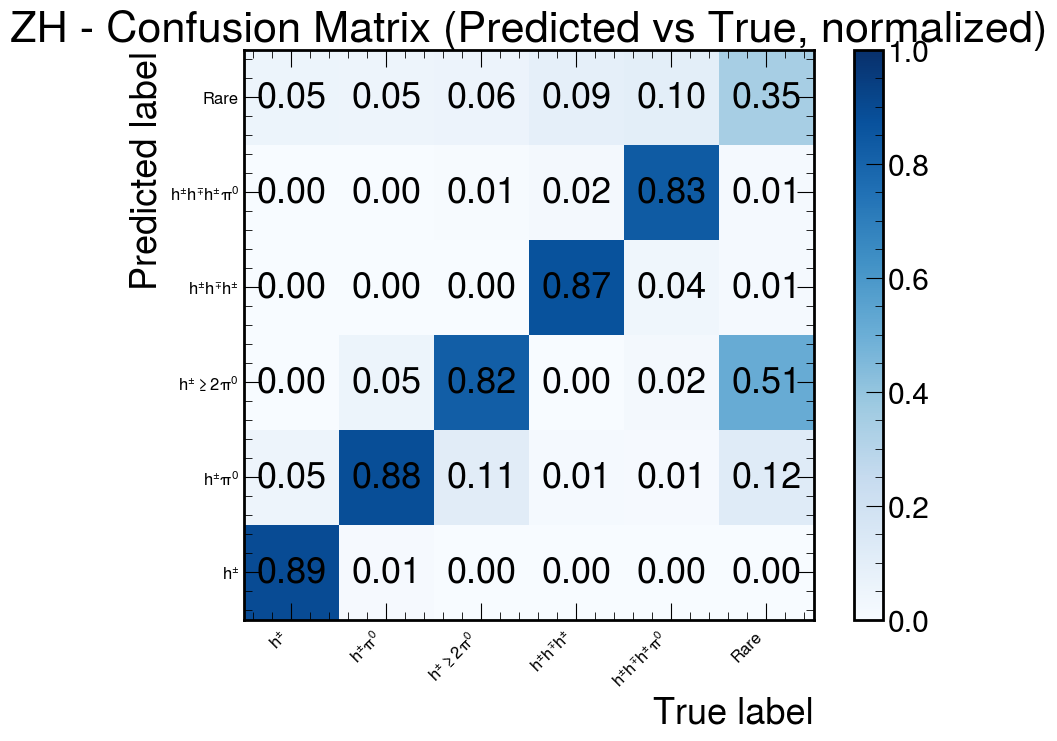

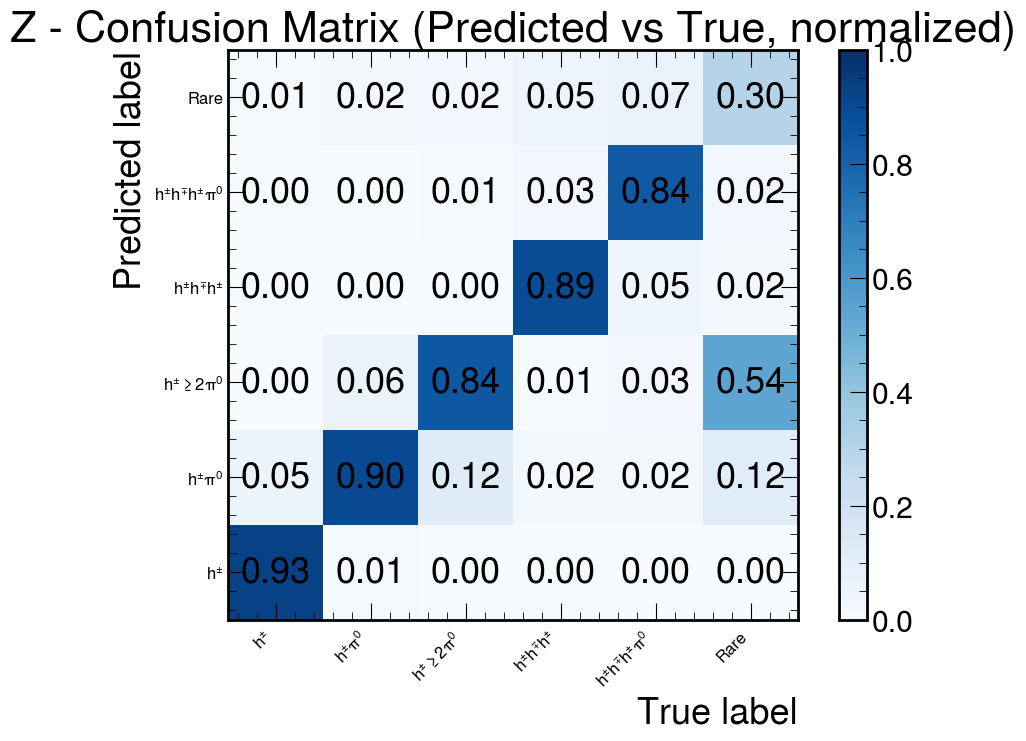

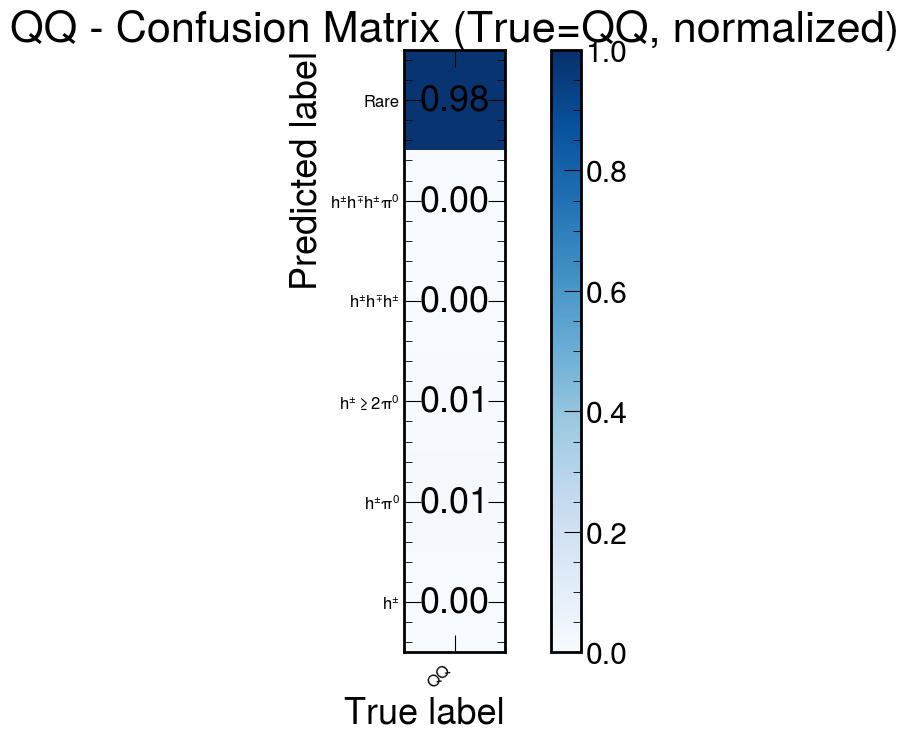

In [17]:
class_names = [
    r'$h^{\pm}$',
    r'$h^{\pm}\pi^0$',
    r'$h^{\pm}\geq 2\pi^0$',
    r'$h^{\pm}h^{\mp}h^{\pm}$',           
    r'$h^{\pm}h^{\mp}h^{\pm}\pi^0$',      
    'Rare'
]

def plot_confusion_matrix(y_true, y_pred, dataset_name, figsize=(10, 8)):
    """Plot normalized confusion matrix with Predicted vs True orientation"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if not np.issubdtype(y_pred.dtype, np.integer):
        y_pred = np.rint(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(invalid='ignore', divide='ignore'):
        cm_normalized = np.divide(cm.astype('float'), row_sums, where=row_sums != 0)
    cm_normalized[np.isnan(cm_normalized)] = 0

    fig, ax = plt.subplots(figsize=figsize)

    if dataset_name == 'QQ' and np.array_equal(np.unique(y_true), [5]):
        # QQ has a single true label (class 5). Show predicted tau classes on the y-axis
        cm_qq = cm[5:6, :].astype('float')
        total = cm_qq.sum()
        cm_plot = cm_qq / total if total != 0 else np.zeros_like(cm_qq)
        cm_plot = cm_plot.T

        im = ax.imshow(cm_plot, interpolation='nearest', cmap='Blues', origin='lower', vmin=0, vmax=1)
        for i in range(cm_plot.shape[0]):
            for j in range(cm_plot.shape[1]):
                ax.text(j, i, f'{cm_plot[i, j]:.2f}', ha='center', va='center', color='black')

        ax.set_xticks([0])
        ax.set_xticklabels(['QQ'], rotation=45, ha='right', fontsize=12)
        ax.set_yticks(np.arange(len(class_names)))
        ax.set_yticklabels(class_names, fontsize=12)
        ax.set_xlabel('True label')
        ax.set_ylabel('Predicted label')
        ax.set_title(f"{dataset_name} - Confusion Matrix (True=QQ, normalized)")
        fig.colorbar(im, ax=ax)
    else:
        cm_plot = cm_normalized.T
        im = ax.imshow(cm_plot, interpolation='nearest', cmap='Blues', origin='lower', vmin=0, vmax=1)
        for i in range(cm_plot.shape[0]):
            for j in range(cm_plot.shape[1]):
                ax.text(j, i, f'{cm_plot[i, j]:.2f}', ha='center', va='center', color='black')

        ax.set_xticks(np.arange(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=12)
        ax.set_yticks(np.arange(len(class_names)))
        ax.set_yticklabels(class_names, fontsize=12)
        ax.set_xlabel('True label')
        ax.set_ylabel('Predicted label')
        ax.set_title(f"{dataset_name} - Confusion Matrix (Predicted vs True, normalized)")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

    return cm, cm_normalized

cm_zh, cm_zh_norm = plot_confusion_matrix(zh_target, zh_pred, "ZH")
cm_z, cm_z_norm = plot_confusion_matrix(z_target, z_pred, "Z")
cm_qq, cm_qq_norm = plot_confusion_matrix(qq_target, qq_pred, "QQ")

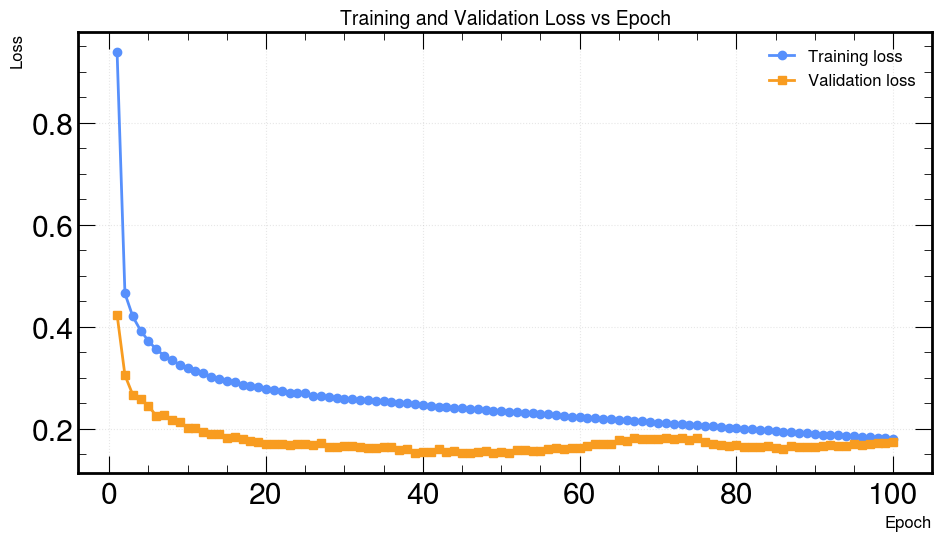

In [18]:
import json

history_path = os.path.join(model_path, "history.json")
with open(history_path, "r") as f:
    history = json.load(f)

loss_train = history.get("loss_train", [])
loss_validation = history.get("loss_validation", [])
epochs = np.arange(1, len(loss_train) + 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, loss_train, label="Training loss", marker="o", linewidth=2)
ax.plot(epochs, loss_validation, label="Validation loss", marker="s", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Training and Validation Loss vs Epoch", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
print(zh_pred_proba.shape)


(1042833,)


## Prediction Confidence Distribution

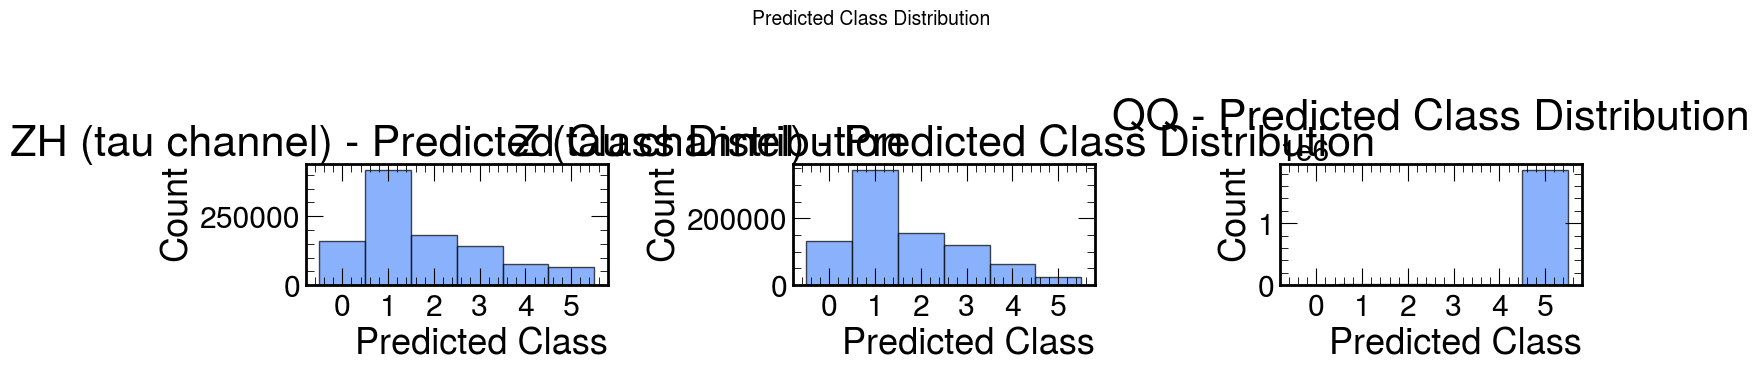

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, preds, name in [
    (axes[0], zh_pred_proba, "ZH (tau channel)"),
    (axes[1], z_pred_proba, "Z (tau channel)"),
    (axes[2], qq_pred_proba, "QQ")
]:
    ax.hist(preds, bins=np.arange(-0.5, 6.5, 1), edgecolor='black', alpha=0.7)
    ax.set_xticks(range(6))
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} - Predicted Class Distribution")

plt.suptitle("Predicted Class Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## Accuracy vs Confidence

In [21]:
def plot_accuracy_vs_confidence(y_true, y_pred, confidence, dataset_name, n_bins=10):
    """Plot accuracy as a function of prediction confidence"""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    accuracies = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (confidence >= bins[i]) & (confidence < bins[i + 1])
        if mask.sum() > 0:
            acc = accuracy_score(y_true[mask], y_pred[mask])
            accuracies.append(acc)
            counts.append(mask.sum())
        else:
            accuracies.append(np.nan)
            counts.append(0)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(bin_centers, accuracies, 'o-', linewidth=2, markersize=8, label='Accuracy', color='blue')
    ax1.set_xlabel('Confidence Bin')
    ax1.set_ylabel('Accuracy', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_ylim([0, 1.05])
    ax1.grid(True, alpha=0.3)
    
    ax2 = ax1.twinx()
    ax2.bar(bin_centers, counts, width=0.08, alpha=0.3, label='Count', color='green')
    ax2.set_ylabel('Number of Predictions', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    
    ax1.set_title(f"{dataset_name} - Accuracy vs Prediction Confidence")
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_accuracy_vs_confidence(zh_target, zh_pred, zh_confidence, "ZH")
plot_accuracy_vs_confidence(z_target, z_pred, z_confidence, "Z")
plot_accuracy_vs_confidence(qq_target, qq_pred, qq_confidence, "QQ")

NameError: name 'zh_confidence' is not defined

## ROC Curves (One-vs-Rest)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

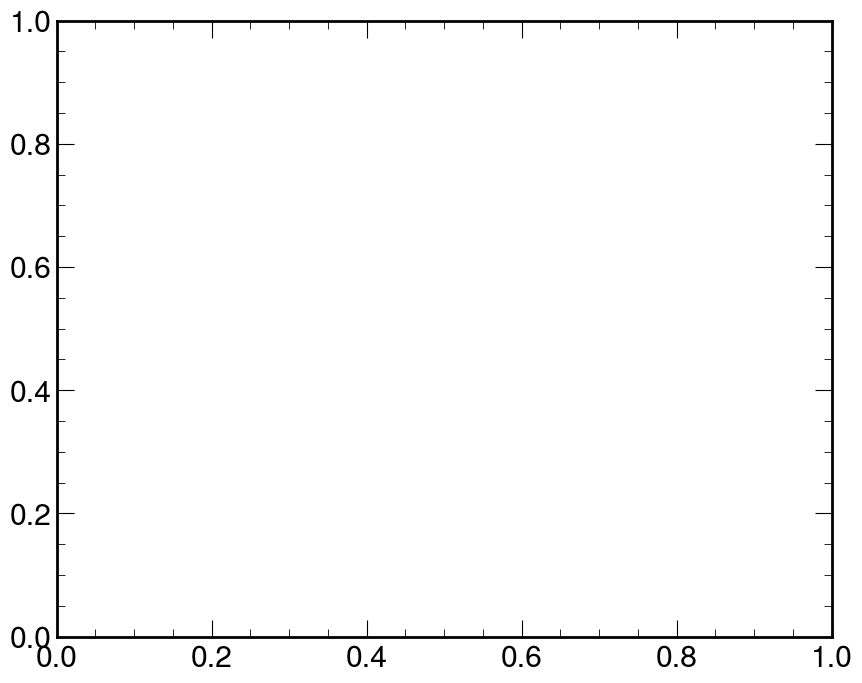

In [ ]:
def plot_roc_curves(y_true, y_pred_proba, dataset_name, n_classes=None):
    """Plot ROC curves for each class (One-vs-Rest)"""
    if n_classes is None:
        n_classes = len(np.unique(y_true))
    
    y_bin = label_binarize(y_true, classes=np.arange(n_classes))
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for i in range(n_classes):
        if np.sum(y_bin[:, i]) == 0:
            continue  # Skip classes with no samples
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.3f})', linewidth=2)
    
    ax.plot([0, 1], [0, 1], 'k--', label='Chance', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f"{dataset_name} - ROC Curves (One-vs-Rest)")
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_roc_curves(zh_target, zh_pred_proba, "ZH")
plot_roc_curves(z_target, z_pred_proba, "Z")
plot_roc_curves(qq_target, qq_pred_proba, "QQ")

## Misclassification Analysis

In [ ]:
def analyze_misclassifications(y_true, y_pred, confidence, dataset_name):
    """Analyze misclassified examples"""
    misclass_mask = y_true != y_pred
    n_misclass = misclass_mask.sum()
    n_total = len(y_true)
    error_rate = n_misclass / n_total
    
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Misclassification Analysis")
    print(f"{'='*60}")
    print(f"Total misclassifications: {n_misclass} / {n_total} ({error_rate*100:.2f}%)")
    print(f"Mean confidence of correct predictions: {np.mean(confidence[~misclass_mask]):.4f}")
    print(f"Mean confidence of misclassifications: {np.mean(confidence[misclass_mask]):.4f}")
    
    # Top 10 most common misclassifications
    misclass_pairs = list(zip(y_true[misclass_mask], y_pred[misclass_mask]))
    from collections import Counter
    pair_counts = Counter(misclass_pairs)
    print(f"\nTop 10 misclassification pairs (true -> pred):")
    for (true_class, pred_class), count in pair_counts.most_common(10):
        print(f"  Class {true_class} -> Class {pred_class}: {count} times")

analyze_misclassifications(zh_target, zh_pred, zh_confidence, "ZH")
analyze_misclassifications(z_target, z_pred, z_confidence, "Z")
analyze_misclassifications(qq_target, qq_pred, qq_confidence, "QQ")


ZH - Misclassification Analysis
Total misclassifications: 179703 / 1042833 (17.23%)
Mean confidence of correct predictions: 1.5575
Mean confidence of misclassifications: 2.9612

Top 10 misclassification pairs (true -> pred):
  Class 1 -> Class 2: 51670 times
  Class 1 -> Class 5: 23345 times
  Class 2 -> Class 1: 18351 times
  Class 3 -> Class 5: 12839 times
  Class 2 -> Class 5: 12405 times
  Class 4 -> Class 5: 10220 times
  Class 1 -> Class 0: 9266 times
  Class 0 -> Class 1: 8156 times
  Class 0 -> Class 5: 7160 times
  Class 3 -> Class 4: 4927 times

Z - Misclassification Analysis
Total misclassifications: 137213 / 839828 (16.34%)
Mean confidence of correct predictions: 1.5572
Mean confidence of misclassifications: 2.5371

Top 10 misclassification pairs (true -> pred):
  Class 1 -> Class 2: 45519 times
  Class 2 -> Class 1: 16968 times
  Class 1 -> Class 5: 9429 times
  Class 1 -> Class 0: 7932 times
  Class 0 -> Class 1: 7354 times
  Class 4 -> Class 5: 6997 times
  Class 3 -> C

## Model Performance Summary


Overall Performance Summary
Dataset  Accuracy  F1 (macro)  F1 (weighted)  Precision   Recall
     ZH  0.827678    0.720750       0.853843   0.740568 0.745636
      Z  0.836618    0.719483       0.852035   0.728879 0.743069
     QQ  0.958402    0.163127       0.978759   0.166667 0.159734


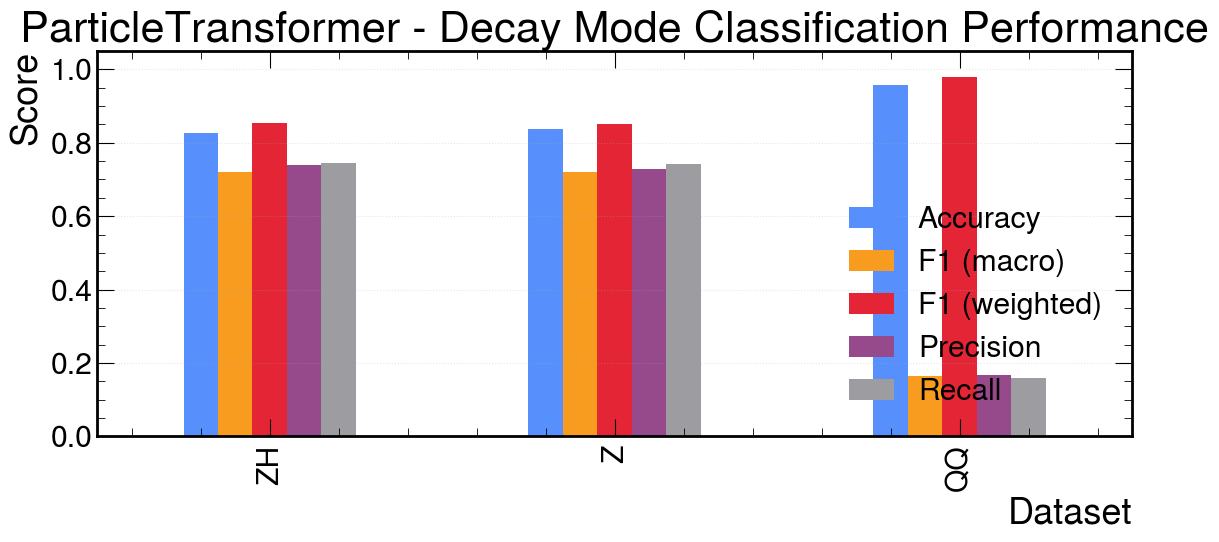

In [ ]:
summary_data = {
    'Dataset': ['ZH', 'Z', 'QQ'],
    'Accuracy': [metrics_zh['accuracy'], metrics_z['accuracy'], metrics_qq['accuracy']],
    'F1 (macro)': [metrics_zh['f1_macro'], metrics_z['f1_macro'], metrics_qq['f1_macro']],
    'F1 (weighted)': [metrics_zh['f1_weighted'], metrics_z['f1_weighted'], metrics_qq['f1_weighted']],
    'Precision': [metrics_zh['precision_macro'], metrics_z['precision_macro'], metrics_qq['precision_macro']],
    'Recall': [metrics_zh['recall_macro'], metrics_z['recall_macro'], metrics_qq['recall_macro']]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("Overall Performance Summary")
print("="*80)
print(summary_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
summary_df.set_index('Dataset')[['Accuracy', 'F1 (macro)', 'F1 (weighted)', 'Precision', 'Recall']].plot(kind='bar', ax=ax)
ax.set_ylabel('Score')
ax.set_title('ParticleTransformer - Decay Mode Classification Performance')
ax.legend(loc='lower right')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 2-epoch no-QQ training (paper-like)

Confusion matrices for `dm_multiclass_epoch2_noQQ_test` (Z train only, no qq).
Plots: **ZH test** and **ZH+Z combined**.

In [22]:
# 2-epoch no-QQ model outputs (distinct names from the 100-epoch run)
# Imports here so this section can run without re-running the 100-epoch cells above
import os
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import mplhep as hep
hep.style.use("CMS")

e2_model_path = (
    "/user/u/urrejola/TauFCC/ml-tau-en-reg/"
    "training-outputs/dm_multiclass_epoch2_noQQ_test/dm_multiclass/ParticleTransformer"
)
e2_zh_test_path = os.path.join(e2_model_path, "zh_test.parquet")
e2_z_test_path = os.path.join(e2_model_path, "z_test.parquet")

e2_zh_full = ak.from_parquet(e2_zh_test_path)
e2_z_full = ak.from_parquet(e2_z_test_path)

e2_zh_test = e2_zh_full["dm_multiclass"]
e2_z_test = e2_z_full["dm_multiclass"]

print("e2 fields ZH:", e2_zh_test.fields)
print("e2 fields Z:", e2_z_test.fields)
print(f"e2 ZH size: {len(e2_zh_test['pred'])}")
print(f"e2 Z size:  {len(e2_z_test['pred'])}")

e2 fields ZH: ['pred', 'target']
e2 fields Z: ['pred', 'target']
e2 ZH size: 1042833
e2 Z size:  839828


In [23]:
# Convert 2-epoch predictions/targets to numpy
e2_zh_target = ak.to_numpy(e2_zh_test.target)
e2_zh_pred = ak.to_numpy(e2_zh_test.pred)
if not np.issubdtype(e2_zh_pred.dtype, np.integer):
    e2_zh_pred = np.rint(e2_zh_pred).astype(int)

e2_z_target = ak.to_numpy(e2_z_test.target)
e2_z_pred = ak.to_numpy(e2_z_test.pred)
if not np.issubdtype(e2_z_pred.dtype, np.integer):
    e2_z_pred = np.rint(e2_z_pred).astype(int)

# Combined ZH + Z test
e2_zh_z_target = np.concatenate([e2_zh_target, e2_z_target])
e2_zh_z_pred = np.concatenate([e2_zh_pred, e2_z_pred])

print(f"e2 ZH:   target={e2_zh_target.shape}, pred={e2_zh_pred.shape}, classes={np.unique(e2_zh_target)}")
print(f"e2 Z:    target={e2_z_target.shape}, pred={e2_z_pred.shape}, classes={np.unique(e2_z_target)}")
print(f"e2 ZH+Z: target={e2_zh_z_target.shape}, pred={e2_zh_z_pred.shape}")

e2 ZH:   target=(1042833,), pred=(1042833,), classes=[0 1 2 3 4 5]
e2 Z:    target=(839828,), pred=(839828,), classes=[0 1 2 3 4 5]
e2 ZH+Z: target=(1882661,), pred=(1882661,)


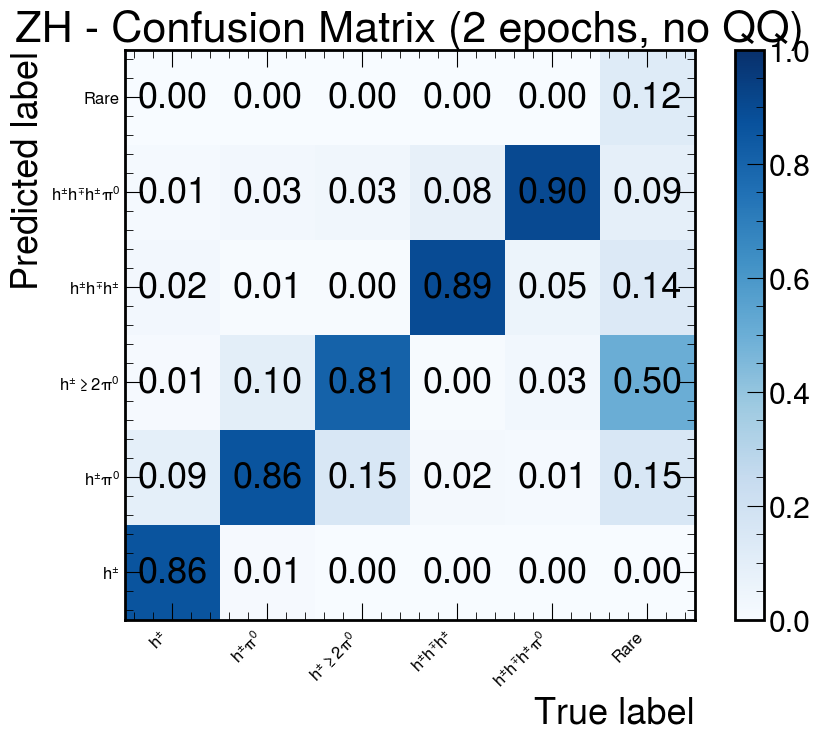

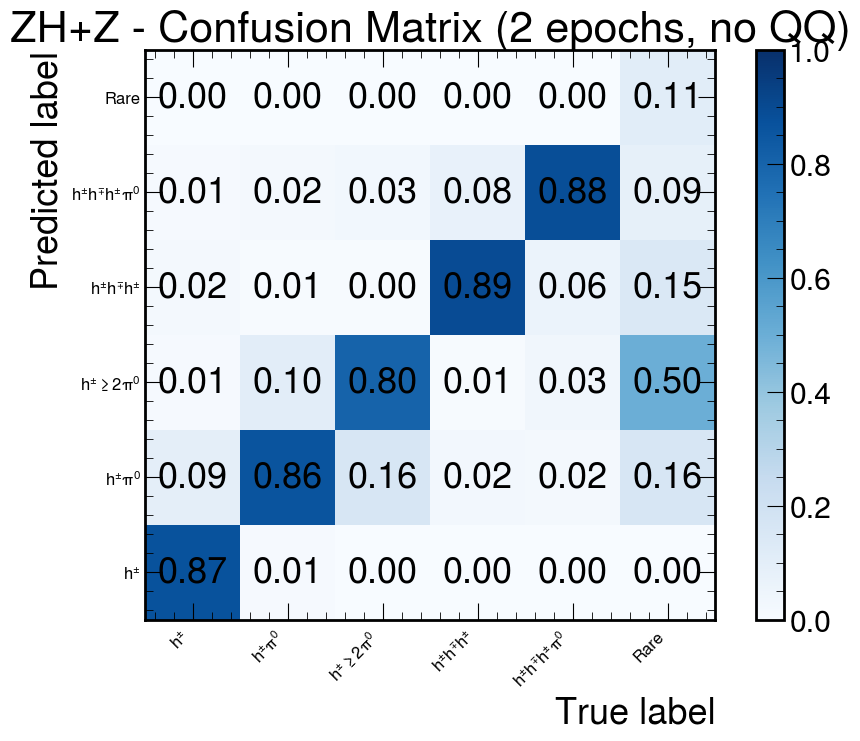

In [25]:
# Confusion matrices for 2-epoch no-QQ run only: ZH and ZH+Z
e2_class_names = [
    r"$h^{\pm}$",
    r"$h^{\pm}\pi^0$",
    r"$h^{\pm}\geq 2\pi^0$",
    r"$h^{\pm}h^{\mp}h^{\pm}$",
    r"$h^{\pm}h^{\mp}h^{\pm}\pi^0$",
    "Rare",
]

def plot_confusion_matrix_e2(y_true, y_pred, dataset_name, figsize=(10, 8)):
    """Row-normalized CM (Predicted vs True), same style as paper-like plots."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if not np.issubdtype(y_pred.dtype, np.integer):
        y_pred = np.rint(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(e2_class_names)))
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(invalid="ignore", divide="ignore"):
        cm_normalized = np.divide(cm.astype(float), row_sums, where=row_sums != 0)
    cm_normalized[np.isnan(cm_normalized)] = 0

    cm_plot = cm_normalized.T
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_plot, interpolation="nearest", cmap="Blues", origin="lower", vmin=0, vmax=1)
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            ax.text(j, i, f"{cm_plot[i, j]:.2f}", ha="center", va="center", color="black")

    ax.set_xticks(np.arange(len(e2_class_names)))
    ax.set_xticklabels(e2_class_names, rotation=45, ha="right", fontsize=12)
    ax.set_yticks(np.arange(len(e2_class_names)))
    ax.set_yticklabels(e2_class_names, fontsize=12)
    ax.set_xlabel("True label")
    ax.set_ylabel("Predicted label")
    ax.set_title(f"{dataset_name} - Confusion Matrix (2 epochs, no QQ)")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    return cm, cm_normalized

e2_cm_zh, e2_cm_zh_norm = plot_confusion_matrix_e2(e2_zh_target, e2_zh_pred, "ZH")
e2_cm_zh_z, e2_cm_zh_z_norm = plot_confusion_matrix_e2(e2_zh_z_target, e2_zh_z_pred, "ZH+Z")

## Partial 100-epoch no-QQ run (from `history.json`)

Confusion matrices from **training/validation during the run** (not ZH/Z test — those appear only after the job finishes).
Uses the **best validation-loss epoch** so far.

Epochs logged: 14 (0..13)
Best val epoch: 12  val_loss=0.2584  train_loss=0.2538


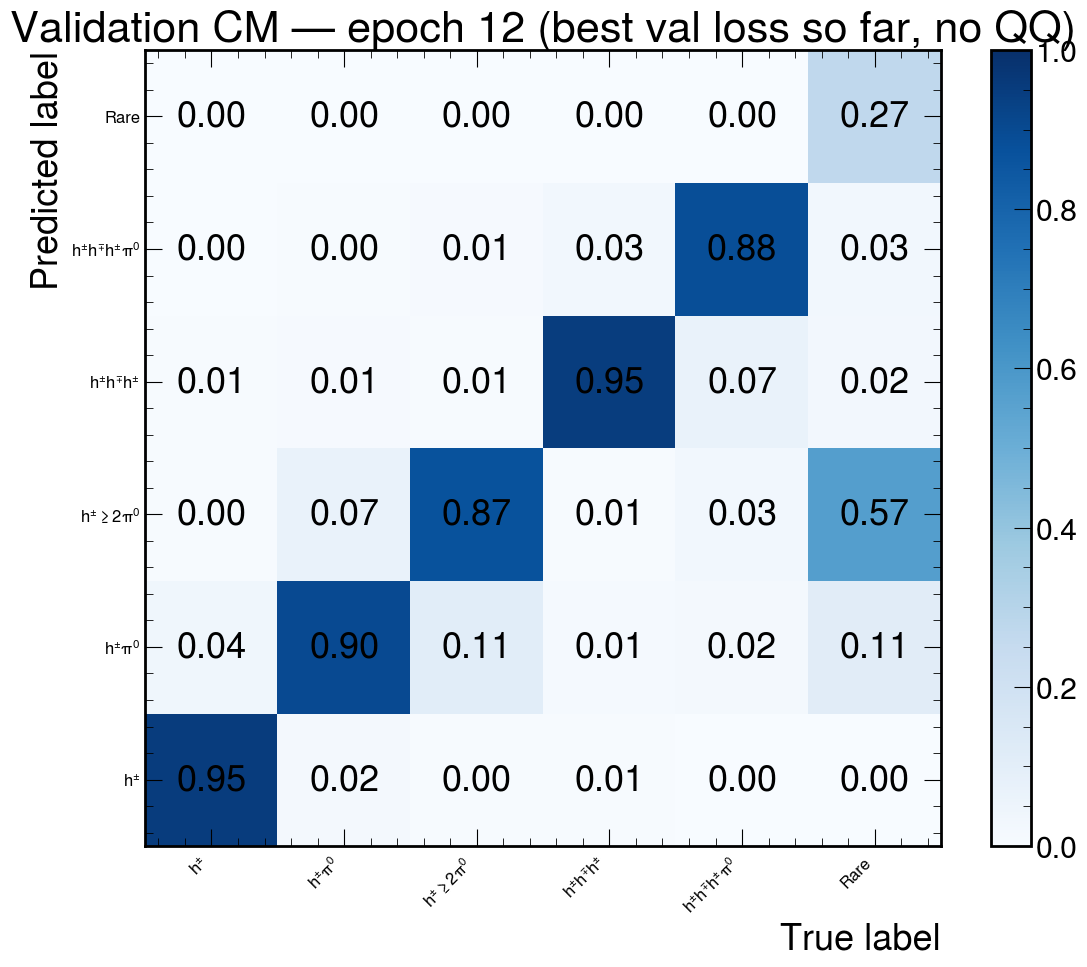

Support: [110260 279998 121328 103175  55007   2773]
Diagonal recall %: [95.1 89.9 87.  94.8 88.3 26.9]


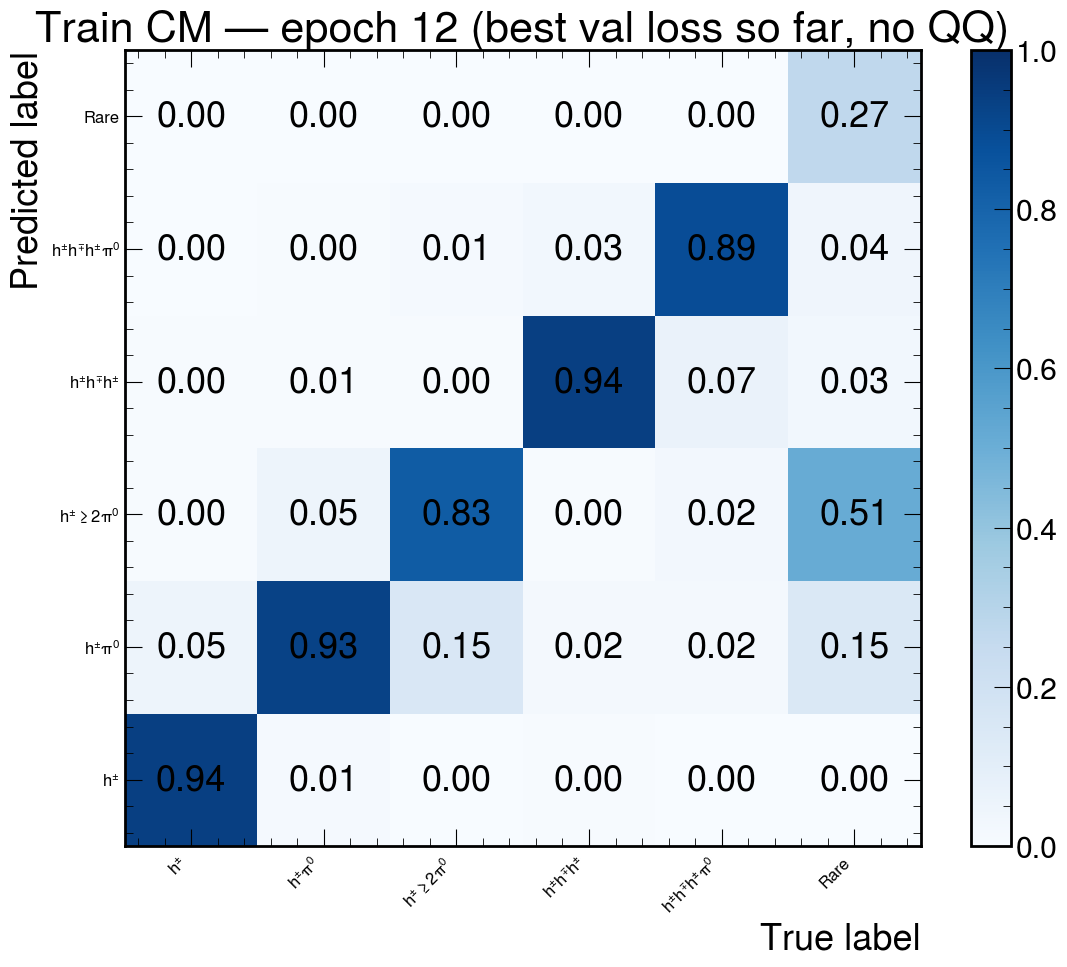

Support: [157340 402589 174260 148293  78841   3931]
Diagonal recall %: [94.  92.6 83.2 93.8 88.8 26.8]


In [26]:
# Partial CMs from ongoing 100-epoch training (history.json)
import json
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

e100_history_path = (
    "/user/u/urrejola/TauFCC/ml-tau-en-reg/"
    "training-outputs/dm_multiclass_epoch100_noQQ/dm_multiclass/ParticleTransformer/history.json"
)
with open(e100_history_path) as f:
    e100_hist = json.load(f)

e100_n = len(e100_hist["loss_validation"])
e100_best = int(np.argmin(e100_hist["loss_validation"]))
print(f"Epochs logged: {e100_n} (0..{e100_n-1})")
print(
    f"Best val epoch: {e100_best}  "
    f"val_loss={e100_hist['loss_validation'][e100_best]:.4f}  "
    f"train_loss={e100_hist['loss_train'][e100_best]:.4f}"
)

e100_class_names = [
    r"$h^{\pm}$",
    r"$h^{\pm}\pi^0$",
    r"$h^{\pm}\geq 2\pi^0$",
    r"$h^{\pm}h^{\mp}h^{\pm}$",
    r"$h^{\pm}h^{\mp}h^{\pm}\pi^0$",
    "Rare",
]

def plot_cm_from_counts(cm, title, figsize=(12, 10)):
    cm = np.asarray(cm, dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(invalid="ignore", divide="ignore"):
        cm_norm = np.divide(cm, row_sums, where=row_sums != 0)
    cm_norm[np.isnan(cm_norm)] = 0

    cm_plot = cm_norm.T  # Predicted vs True (same orientation as before)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_plot, interpolation="nearest", cmap="Blues", origin="lower", vmin=0, vmax=1)
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            ax.text(j, i, f"{cm_plot[i, j]:.2f}", ha="center", va="center", color="black")

    ax.set_xticks(np.arange(len(e100_class_names)))
    ax.set_xticklabels(e100_class_names, rotation=45, ha="right", fontsize=12)
    ax.set_yticks(np.arange(len(e100_class_names)))
    ax.set_yticklabels(e100_class_names, fontsize=12)
    ax.set_xlabel("True label")
    ax.set_ylabel("Predicted label")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    print("Support:", cm.sum(1).astype(int))
    print("Diagonal recall %:", np.round(100 * np.diag(cm_norm), 1))
    return cm, cm_norm

e100_cm_val, e100_cm_val_norm = plot_cm_from_counts(
    e100_hist["confusion_matrix_validation"][e100_best],
    f"Validation CM — epoch {e100_best} (best val loss so far, no QQ)",
)
e100_cm_train, e100_cm_train_norm = plot_cm_from_counts(
    e100_hist["confusion_matrix_train"][e100_best],
    f"Train CM — epoch {e100_best} (best val loss so far, no QQ)",
)

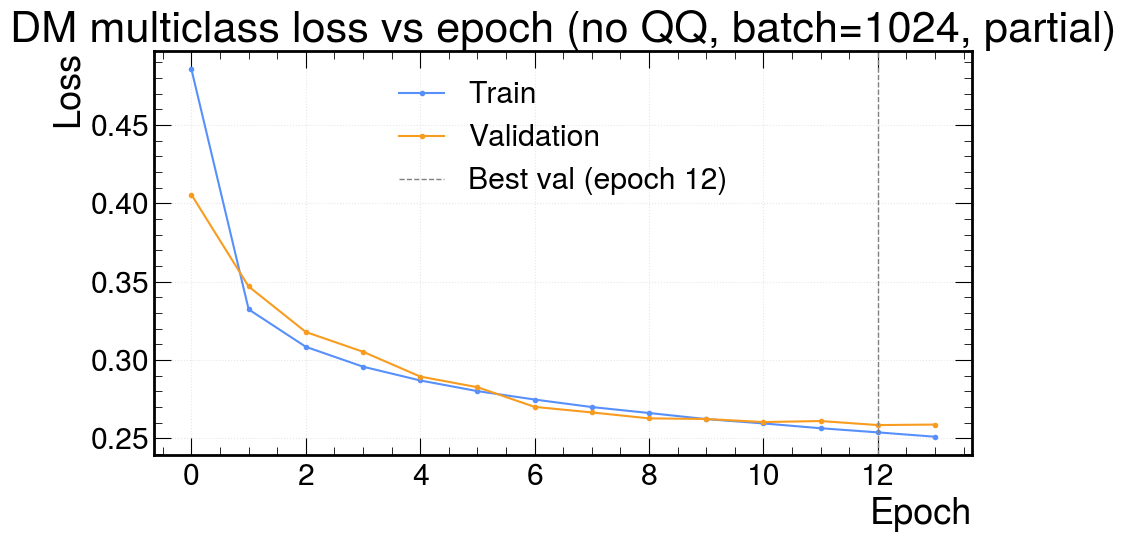

Latest: train=0.2510  val=0.2588
Best val: epoch 12  val=0.2584


In [27]:
# Loss vs epoch for the ongoing 100-epoch no-QQ run
fig, ax = plt.subplots(figsize=(10, 6))
epochs = np.arange(e100_n)
ax.plot(epochs, e100_hist["loss_train"], label="Train", marker="o", markersize=3)
ax.plot(epochs, e100_hist["loss_validation"], label="Validation", marker="o", markersize=3)
ax.axvline(e100_best, color="gray", ls="--", lw=1, label=f"Best val (epoch {e100_best})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("DM multiclass loss vs epoch (no QQ, batch=1024, partial)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Latest: train={e100_hist['loss_train'][-1]:.4f}  val={e100_hist['loss_validation'][-1]:.4f}")
print(f"Best val: epoch {e100_best}  val={e100_hist['loss_validation'][e100_best]:.4f}")

## Completed 100-epoch runs (no QQ) — loss + ZH / ZH+Z CMs

Both runs: **Z train only**, **batch=1024**, **100 epochs**, test on **Z + ZH**.

| Run | `output_dir` | Main difference |
|---|---|---|
| **A — Omni features** | `dm_multiclass_epoch100_noQQ` | `cand_omni_features_wPID` (10-D: raw \(p_T\), mass, …) |
| **B — ParT / paper-like features** | `dm_multiclass_epoch100_noQQ_ParTfeats` | `cand_ParT_features` (13-D: \(\log p_T\), \(\log E\), …) |

Confusion matrices use **test** predictions (best val checkpoint). CMs shown: **ZH** and **ZH+Z**.

In [ ]:
# Shared imports + helpers for the two completed 100-epoch runs
import os
import json
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import mplhep as hep

hep.style.use("CMS")

CLASS_NAMES_100 = [
    r"$h^{\pm}$",
    r"$h^{\pm}\pi^0$",
    r"$h^{\pm}\geq 2\pi^0$",
    r"$h^{\pm}h^{\mp}h^{\pm}$",
    r"$h^{\pm}h^{\mp}h^{\pm}\pi^0$",
    "Rare",
]

def load_test_preds(model_dir):
    zh = ak.from_parquet(os.path.join(model_dir, "zh_test.parquet"))["dm_multiclass"]
    z = ak.from_parquet(os.path.join(model_dir, "z_test.parquet"))["dm_multiclass"]
    zh_t = ak.to_numpy(zh.target)
    zh_p = ak.to_numpy(zh.pred)
    z_t = ak.to_numpy(z.target)
    z_p = ak.to_numpy(z.pred)
    if not np.issubdtype(zh_p.dtype, np.integer):
        zh_p = np.rint(zh_p).astype(int)
    if not np.issubdtype(z_p.dtype, np.integer):
        z_p = np.rint(z_p).astype(int)
    return {
        "zh_target": zh_t,
        "zh_pred": zh_p,
        "z_target": z_t,
        "z_pred": z_p,
        "zh_z_target": np.concatenate([zh_t, z_t]),
        "zh_z_pred": np.concatenate([zh_p, z_p]),
    }

def plot_loss_vs_epoch(history, run_title):
    n = len(history["loss_validation"])
    best = int(np.argmin(history["loss_validation"]))
    epochs = np.arange(n)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs, history["loss_train"], label="Train", marker="o", markersize=2)
    ax.plot(epochs, history["loss_validation"], label="Validation", marker="o", markersize=2)
    ax.axvline(best, color="gray", ls="--", lw=1, label=f"Best val (epoch {best})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(run_title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(
        f"epochs={n}  best={best}  "
        f"best_val={history['loss_validation'][best]:.4f}  "
        f"best_train={history['loss_train'][best]:.4f}  "
        f"final_val={history['loss_validation'][-1]:.4f}"
    )
    return best

def plot_cm(y_true, y_pred, title, figsize=(12, 10)):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES_100)))
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(invalid="ignore", divide="ignore"):
        cm_norm = np.divide(cm.astype(float), row_sums, where=row_sums != 0)
    cm_norm[np.isnan(cm_norm)] = 0
    cm_plot = cm_norm.T
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_plot, interpolation="nearest", cmap="Blues", origin="lower", vmin=0, vmax=1)
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            ax.text(j, i, f"{cm_plot[i, j]:.2f}", ha="center", va="center", color="black")
    ax.set_xticks(np.arange(len(CLASS_NAMES_100)))
    ax.set_xticklabels(CLASS_NAMES_100, rotation=45, ha="right", fontsize=12)
    ax.set_yticks(np.arange(len(CLASS_NAMES_100)))
    ax.set_yticklabels(CLASS_NAMES_100, fontsize=12)
    ax.set_xlabel("True label")
    ax.set_ylabel("Predicted label")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    print("Support:", cm.sum(1).astype(int))
    print("Diagonal recall %:", np.round(100 * np.diag(cm_norm), 1))
    return cm, cm_norm

def summarize_run(model_dir, run_title_prefix):
    hist = json.load(open(os.path.join(model_dir, "history.json")))
    best = plot_loss_vs_epoch(
        hist,
        f"{run_title_prefix} — loss vs epoch",
    )
    data = load_test_preds(model_dir)
    plot_cm(
        data["zh_target"],
        data["zh_pred"],
        f"{run_title_prefix} — ZH test CM (best checkpoint)",
    )
    plot_cm(
        data["zh_z_target"],
        data["zh_z_pred"],
        f"{run_title_prefix} — ZH+Z test CM (best checkpoint)",
    )
    return hist, data, best

print("Helpers ready.")

### Run A — Omni features (`cand_omni_features_wPID`)

**Diff vs paper:** uses Omni-style 10-D features (raw \(p_T\), mass, \(\Delta\eta\), \(\Delta\phi\), charge, PID), not ParT/paper \(\log p_T\)/\(\log E\) features. Still: no QQ, Z-only train, batch 1024.

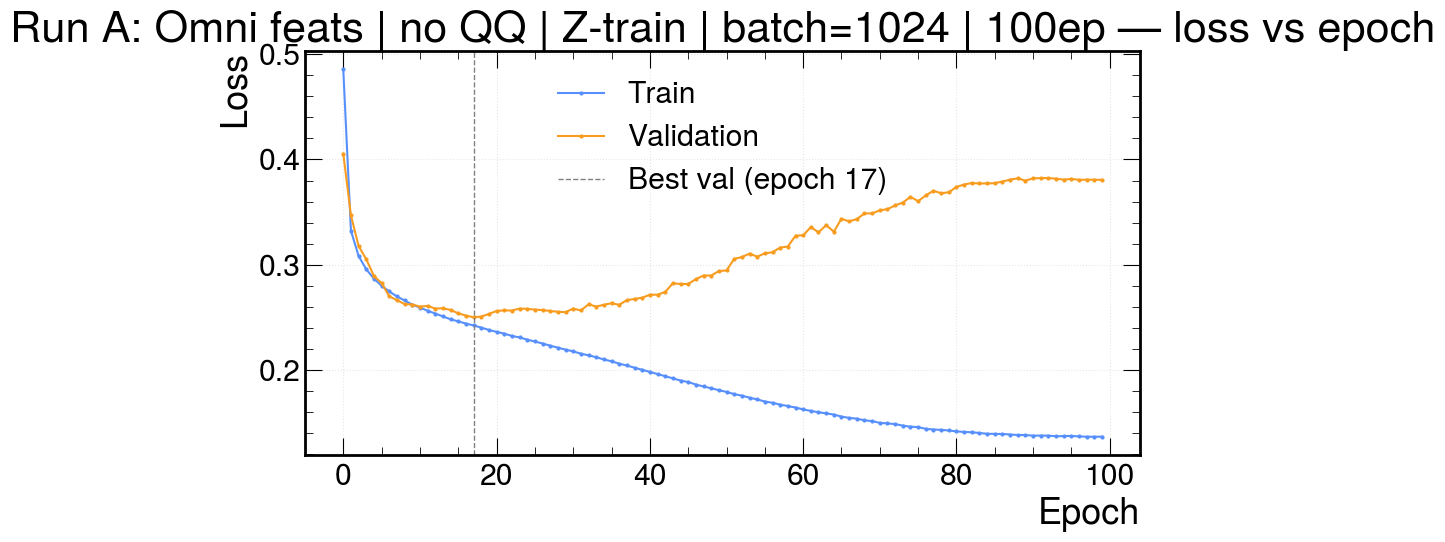

epochs=100  best=17  best_val=0.2502  best_train=0.2425  final_val=0.3806


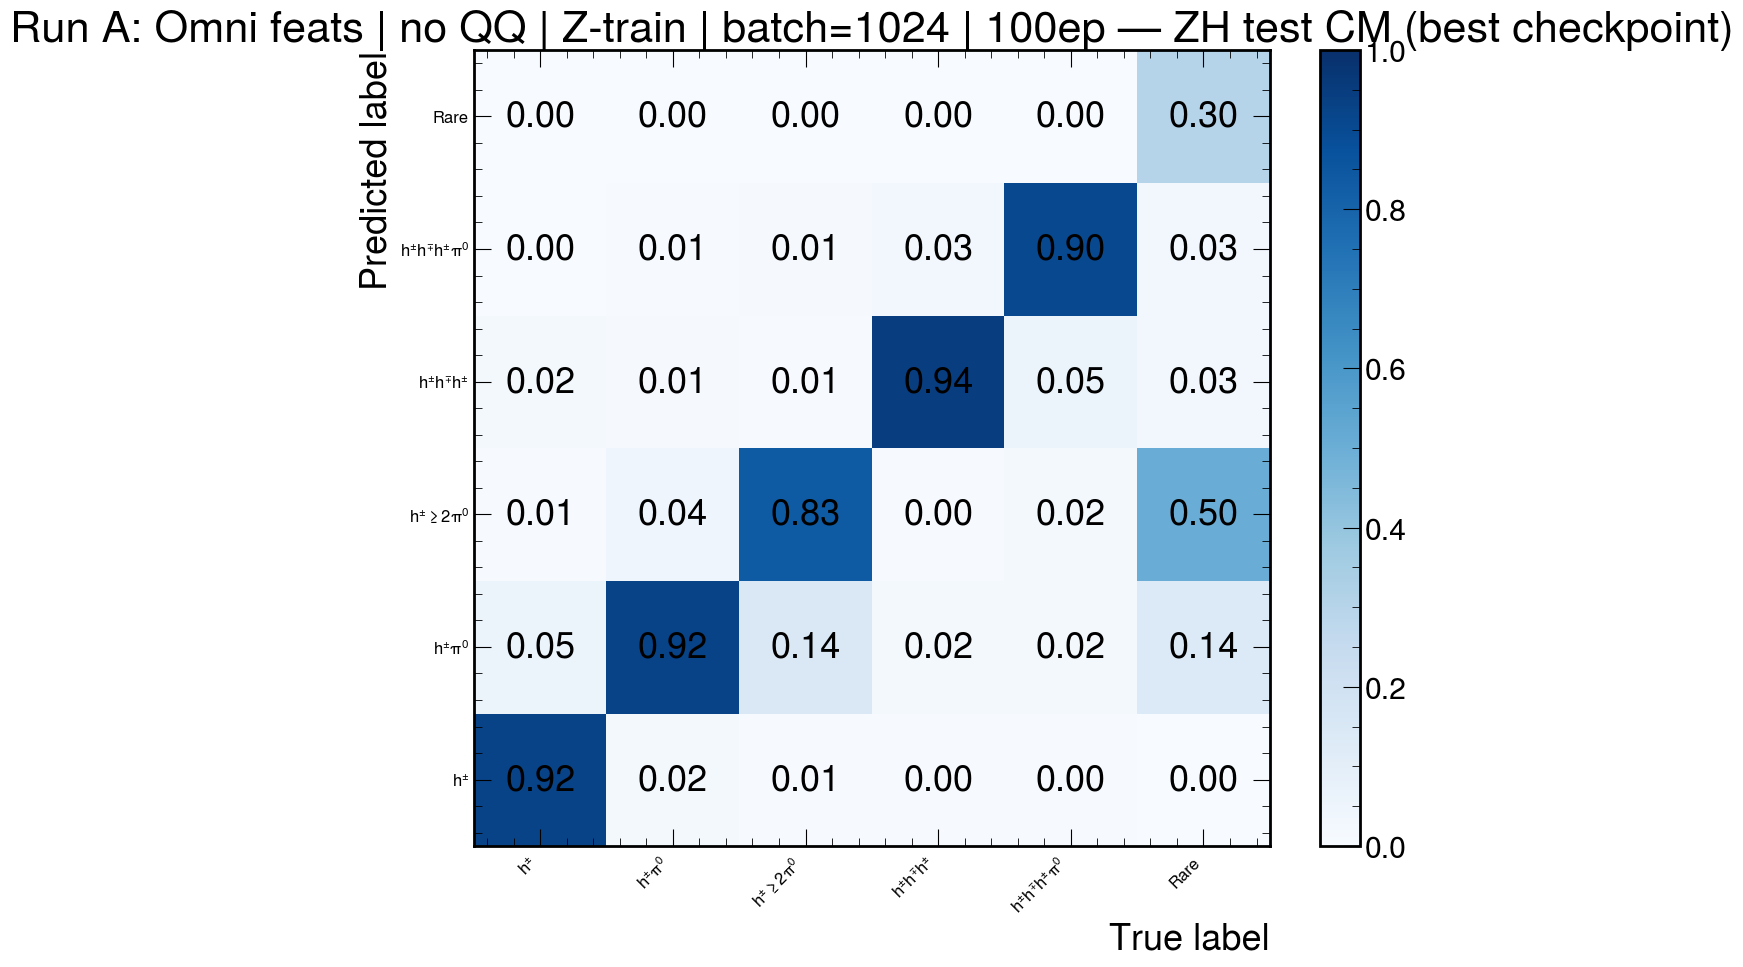

Support: [172244 434683 187805 159340  84445   4316]
Diagonal recall %: [92.4 92.3 83.3 94.5 90.5 30.1]


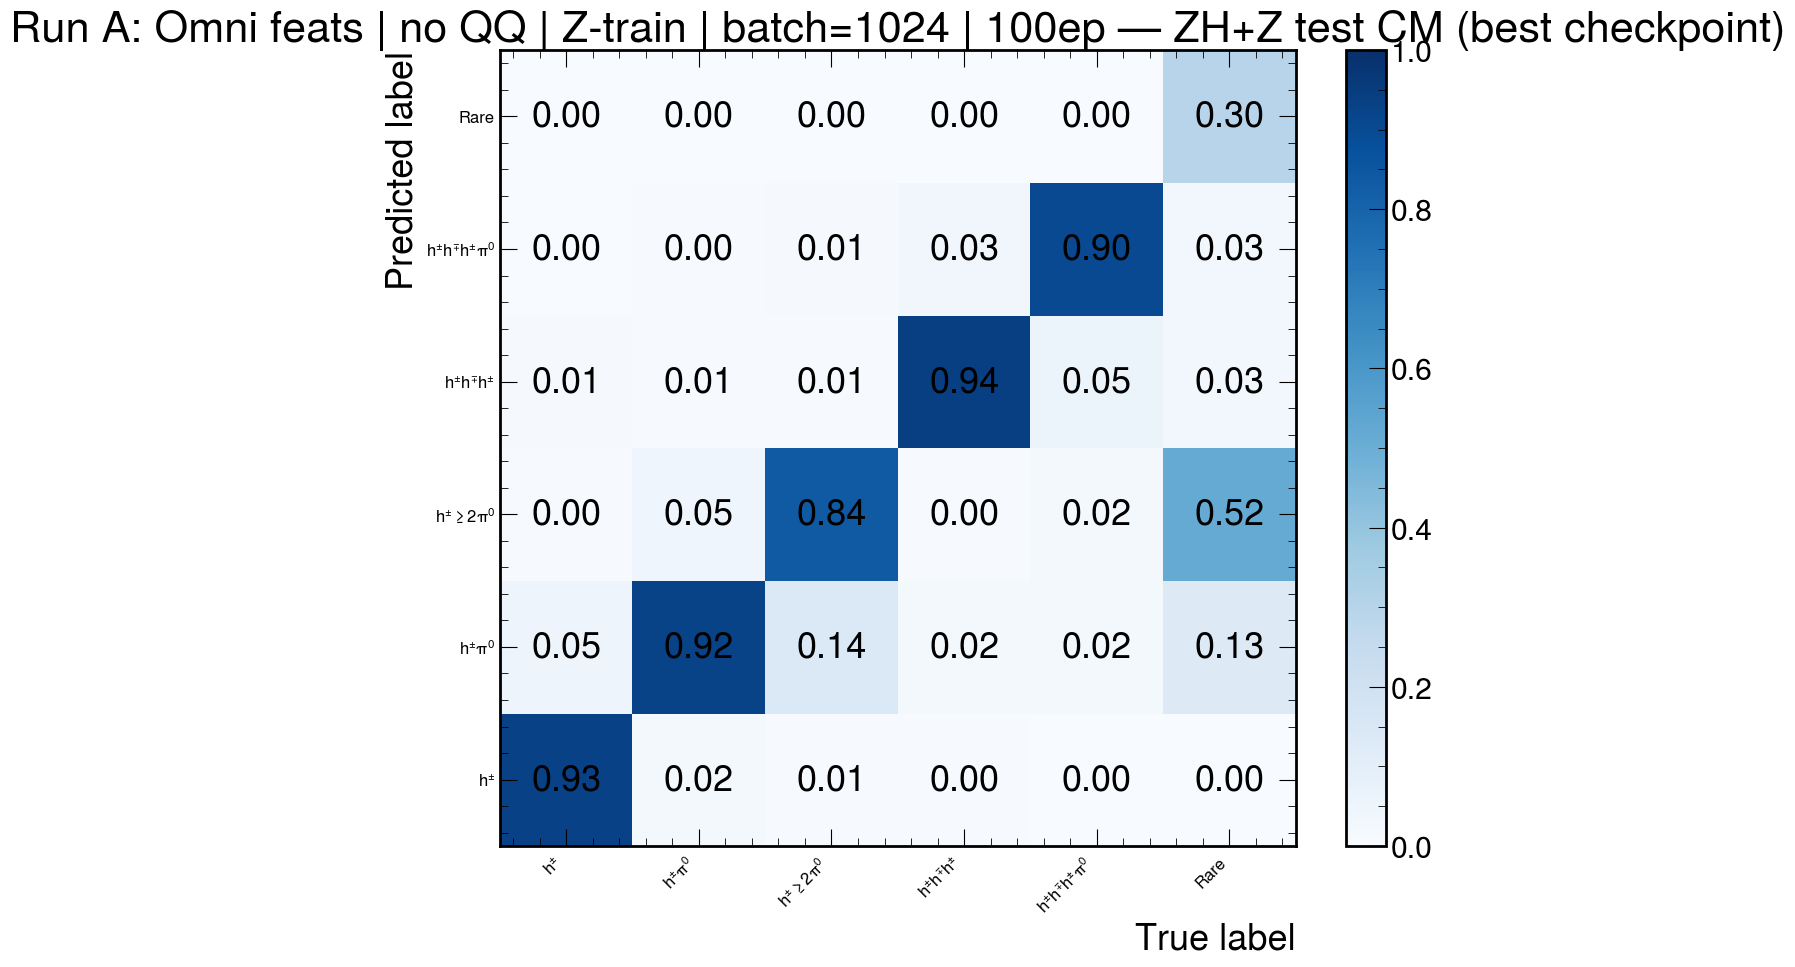

Support: [309198 784550 339096 288438 153578   7801]
Diagonal recall %: [93.3 92.3 83.8 94.  90.  29.5]


In [ ]:
runA_dir = (
    "/user/u/urrejola/TauFCC/ml-tau-en-reg/"
    "training-outputs/dm_multiclass_epoch100_noQQ/dm_multiclass/ParticleTransformer"
)
runA_hist, runA_data, runA_best = summarize_run(
    runA_dir,
    "Run A: Omni feats | no QQ | Z-train | batch=1024 | 100ep",
)

### Run B — ParT / paper-like features (`cand_ParT_features`)

**Closest to the paper feature set** among these two: 13-D ParT features (\(\log p_T\), \(\log E\), relatives, \(\Delta R\), charge, PID). Same setup otherwise: no QQ, Z-only train, batch 1024.

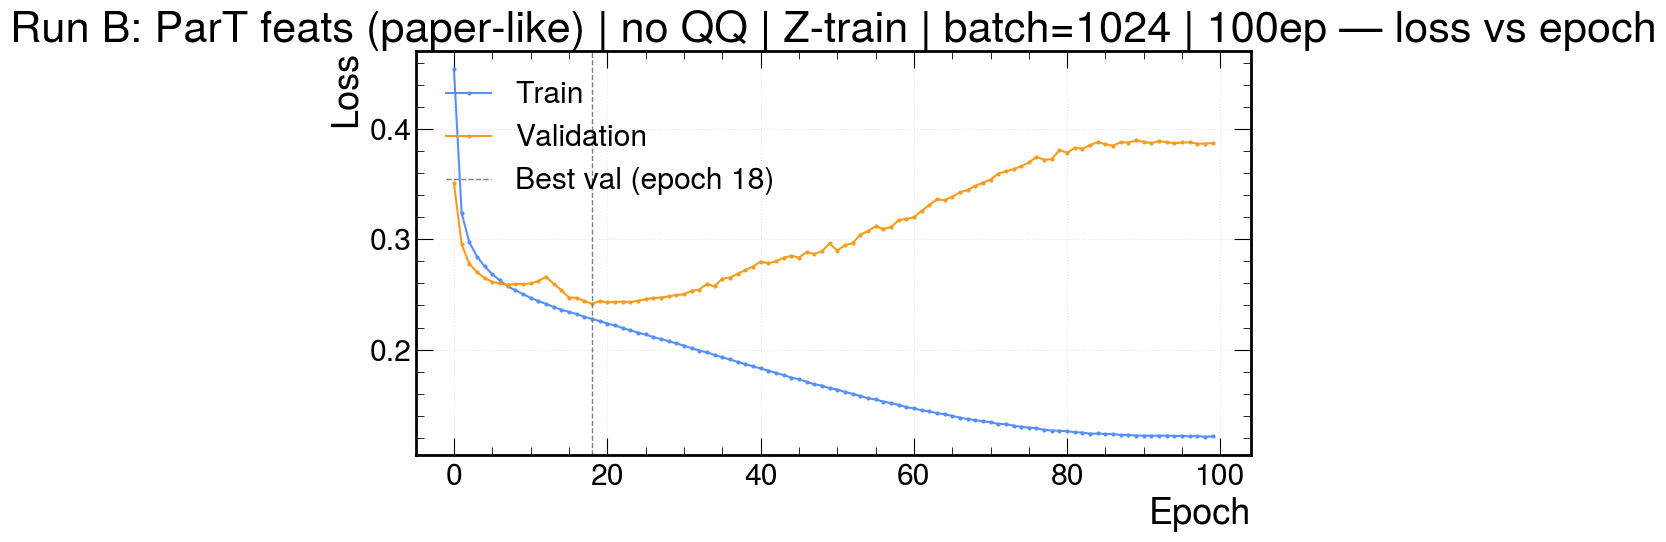

epochs=100  best=18  best_val=0.2415  best_train=0.2278  final_val=0.3874


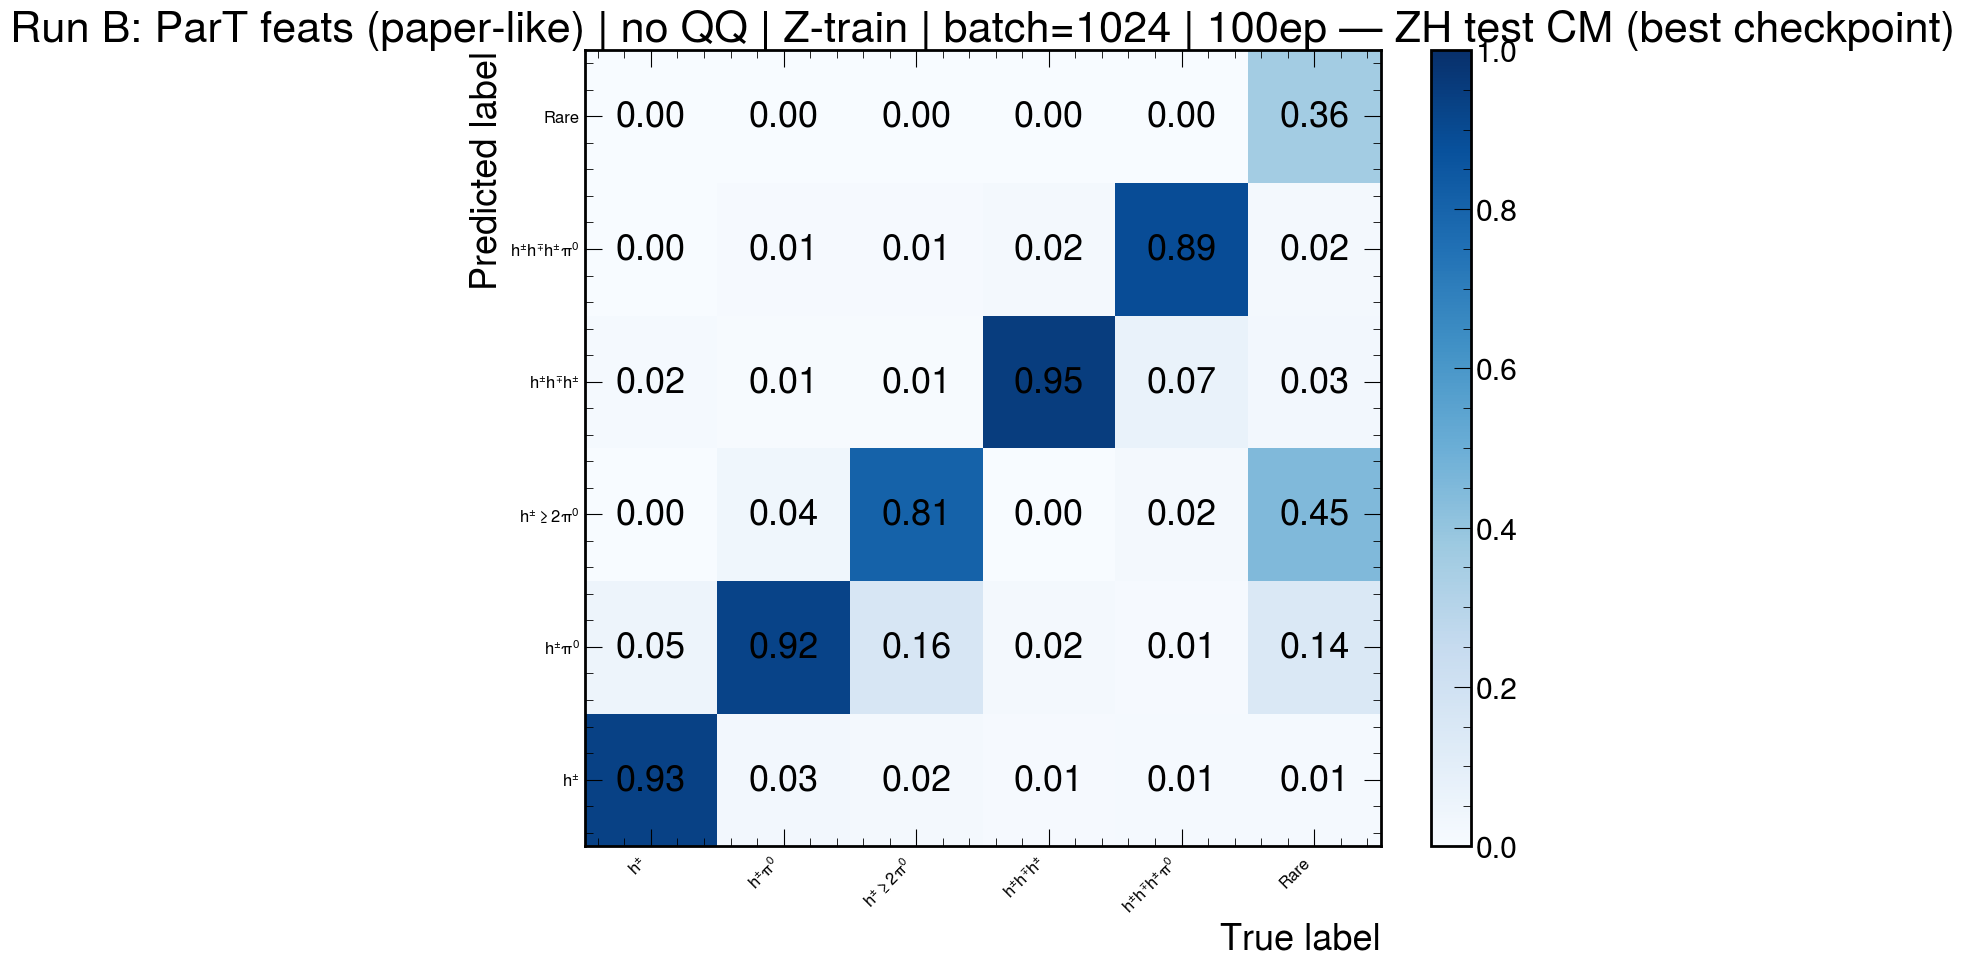

Support: [172244 434683 187805 159340  84445   4316]
Diagonal recall %: [93.  92.3 80.6 94.8 89.  35.9]


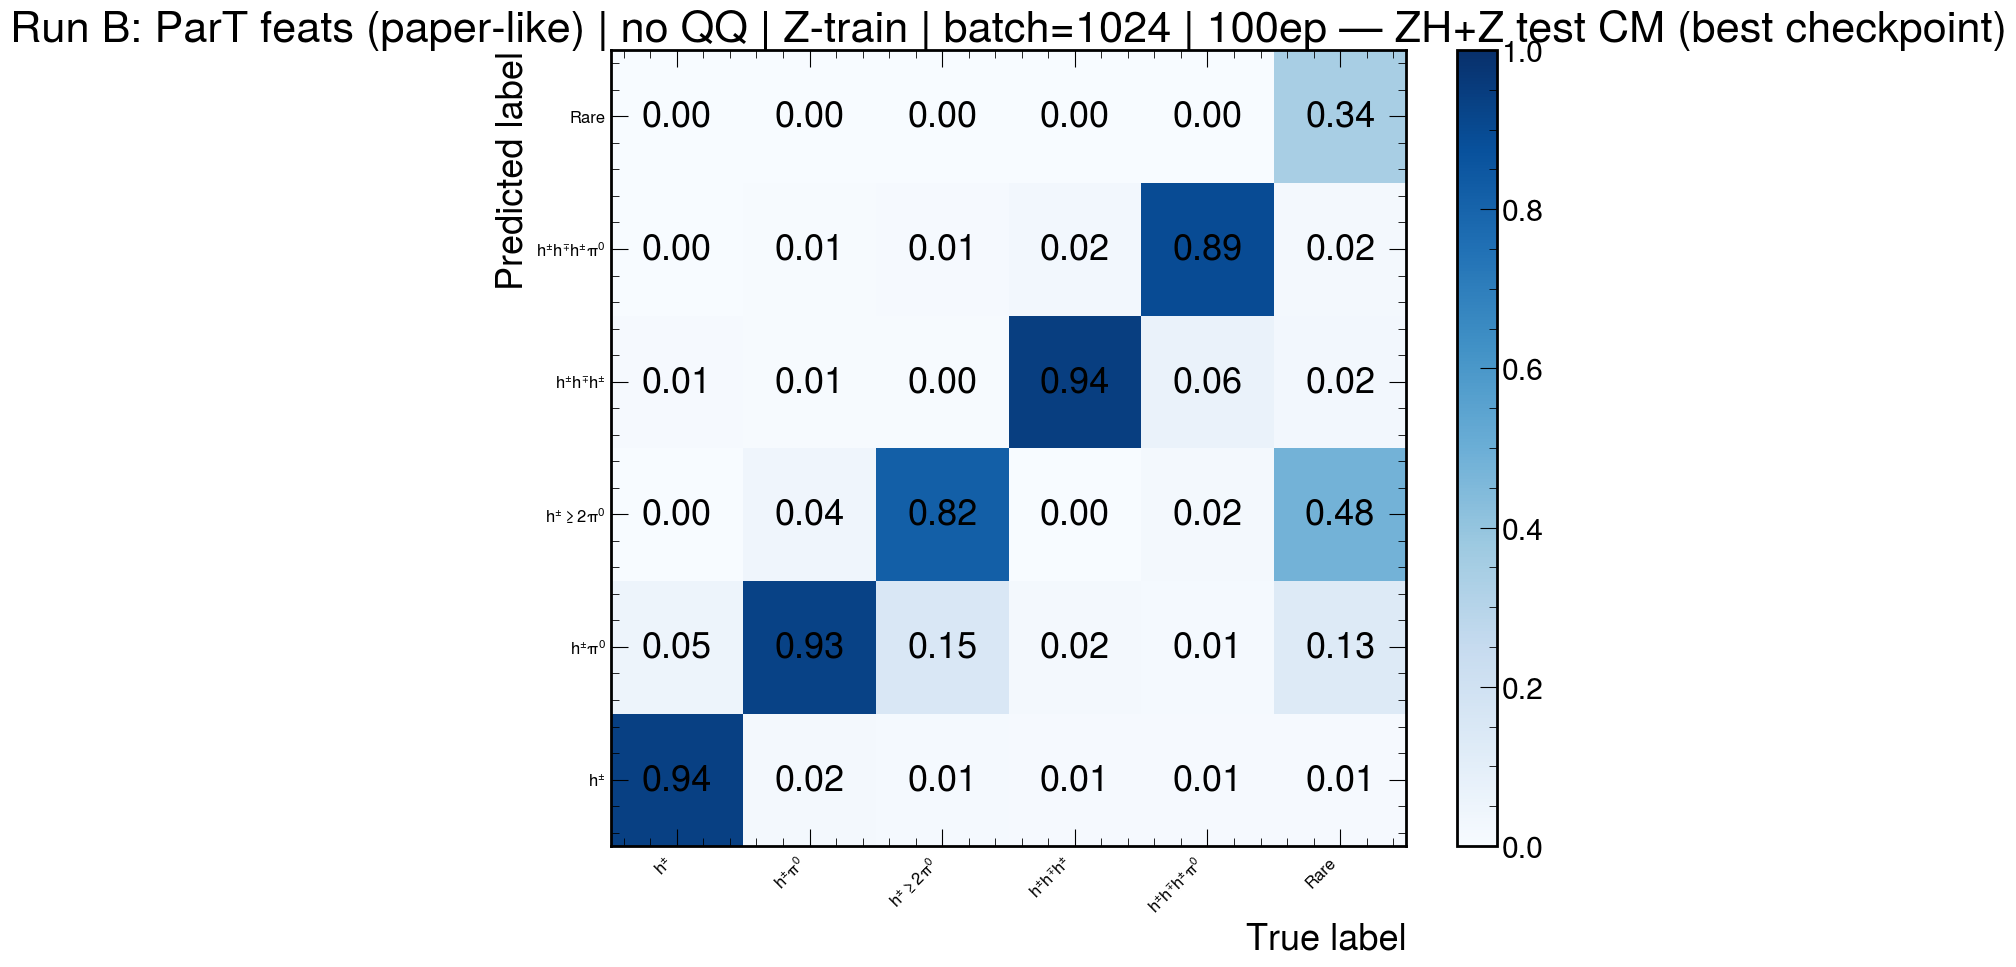

Support: [309198 784550 339096 288438 153578   7801]
Diagonal recall %: [93.7 92.6 81.9 94.3 89.3 34.3]


In [5]:
runB_dir = (
    "/user/u/urrejola/TauFCC/ml-tau-en-reg/"
    "training-outputs/dm_multiclass_epoch100_noQQ_ParTfeats/dm_multiclass/ParticleTransformer"
)
runB_hist, runB_data, runB_best = summarize_run(
    runB_dir,
    "Run B: ParT feats (paper-like) | no QQ | Z-train | batch=1024 | 100ep",
)